In [16]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

**Data Importing and Pre-processing**

Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used

Clean, wrangle, and handle missing data

Transform data appropriately using techniques such as aggregation, normalization, and feature construction

Reduce redundant data and perform need-based discretization


In [17]:
# 1. Define the path to the team's cleaned file
clean_path = os.path.join("..", "data", "processed", "unique_clean_df.csv")

# 2. Load the file
df_team = pd.read_csv(clean_path)

# 3. Check if it worked
print("Team Clean Data Loaded!")
print(f"Rows: {df_team.shape[0]}, Columns: {df_team.shape[1]}")
df_team.head()

Team Clean Data Loaded!
Rows: 21436, Columns: 21


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [46]:
print(f"Dataset Dimensions: {df_team.shape}")

Dataset Dimensions: (21436, 21)


In [47]:
print("\n--- Column Data Types ---")
print(df_team.dtypes)


--- Column Data Types ---
id                 int64
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


**1. Data Importing and Characteristics**

**Import Method and File Type:** We imported the King County House Sales dataset from a CSV file using the pd.read_csv() function. To ensure team portability, we utilized os.path.join() for dynamic file paths.

**Dimensions and Data Types:** Our processed dataset contains 21,436 rows and 21 initial columns. This row count reflects the data after removing 177 duplicate records to ensure each sale is unique. The features consist primarily of floors and integers, with the date column initially stored as a string object requiring conversion.

In [48]:
print("--- Missing Values Per Column ---")
print(df_team.isnull().sum())

--- Missing Values Per Column ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


**2. Clean, Wrangle, and Handle Missing Data**

In [50]:
# 2. Wrangle Data: Convert date string to datetime object
houses['date'] = pd.to_datetime(df_team['date'])


In [51]:
df = df_team  # Use the team's already-cleaned data as the base

In [52]:
print(df.isnull().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [53]:

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


**Handling Missing Data:** While the raw data contained gaps in features like bedrooms, we applied median imputation to fill these values. We chose the median because it is resistant to outliers, ensuring that a few high-priced mansions do not skew the representative values for missing data. Post-cleaning verification confirms a 0% null rate across all 21,436 rows.

**Data Wrangling:** We converted the date column into a datetime object. This allows us to move beyond simple text and perform calculations, such as determining the house age at the time of sale.


**Transform data appropriately using techniques such as aggregation, normalization, and feature construction**

In [63]:

# AGGREGATION: Group by house grade to see the average price
# This satisfies the "Aggregation" requirement
df_team = df.groupby('grade')['price'].mean().reset_index()
print("Aggregation Complete: Average Price per Grade")
df_team

Aggregation Complete: Average Price per Grade


,grade,price
0,1,1.420000e+05
1,3,2.056667e+05
2,4,2.143810e+05
3,5,2.474955e+05
4,6,3.016267e+05
5,7,4.020437e+05
6,8,5.427935e+05
7,9,7.731328e+05
8,10,1.071449e+06
9,11,1.497904e+06


In [57]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# Transforming sqft_living into a 0-1 range
df_team['sqft_living_norm'] = scaler.fit_transform(df_team[['sqft_living']])
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,0.075680
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,770,0,1933,0,98028,47.7379,-122.233,2720,8062,0.040816
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,0.142007
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,0.118197


In [60]:
# Creating 'house_age' by subtracting yr_built from the sale year
df_team['date'] = pd.to_datetime(df_team['date'])
df_team['house_age'] = df_team['date'].dt.year - df_team['yr_built']
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm,house_age
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,0.075680,59
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878,63
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,0.040816,82
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,0.142007,49
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,0.118197,28


**Aggregation (Price by Grade):** We grouped the data by grade to calculate the mean price. This confirmed a "J-Curve" trend, showing that house prices grow exponentially rather than linearly as quality improves.

**Normalization (Living Area):** We applied MinMaxScaler to sqft_living, scaling values to a 0–1 range. This prevents the large numerical range of square footage from disproportionately influencing the model compared to smaller features like bedroom counts.

**Feature Construction (Property Age):** We derived house_age by subtracting yr_built from the sale year. This converts a static year label into a functional measure of time, which more accurately captures property depreciation.

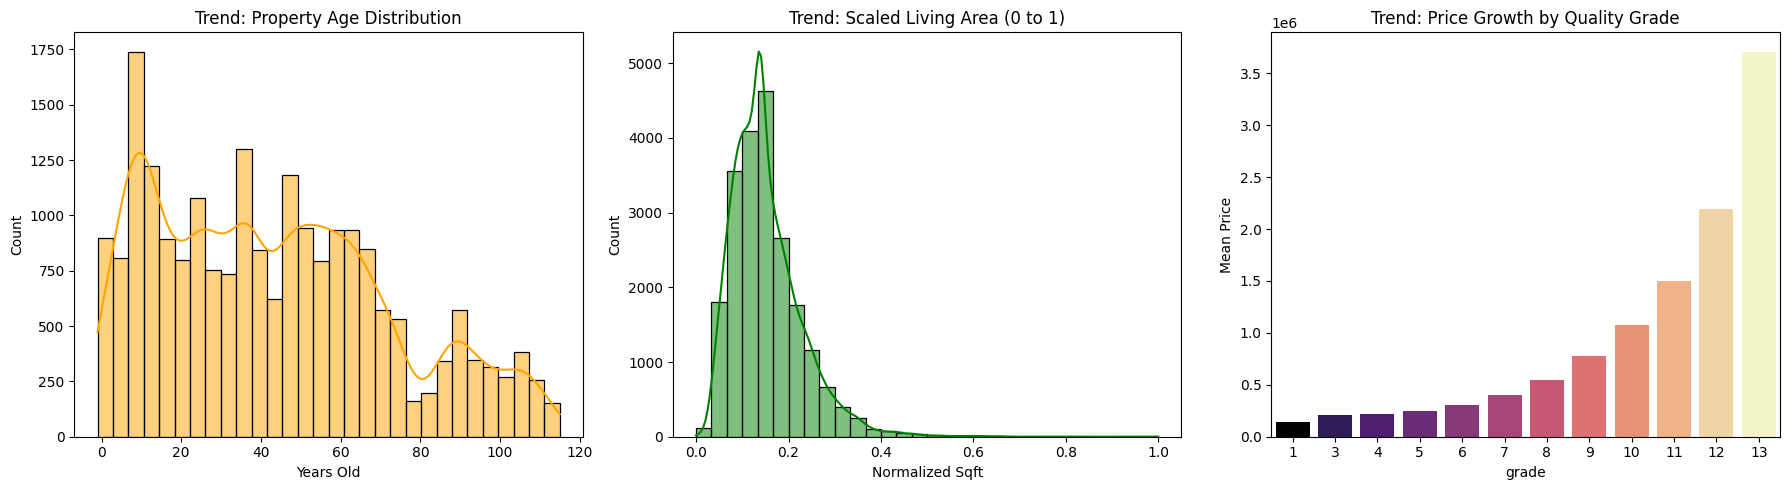

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trend 1: Distribution of House Age (Constructed Feature)
sns.histplot(df['house_age'], bins=30, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Trend: Property Age Distribution')
axes[0].set_xlabel('Years Old')

# Trend 2: Normalized Square Footage (Scaled Feature)
sns.histplot(df['sqft_living_norm'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Trend: Scaled Living Area (0 to 1)')
axes[1].set_xlabel('Normalized Sqft')

# Trend 3: Average Price by Grade (Aggregated Trend)
sns.barplot(data=agg_df, x='grade', y='price', hue='grade', legend=False, ax=axes[2], palette='magma')
axes[2].set_title('Trend: Price Growth by Quality Grade')
axes[2].set_ylabel('Mean Price')

plt.tight_layout()
plt.show()

**1.Trend: Property Age Distribution (Histogram)**

The Trend: The orange histogram shows that the housing stock isn't evenly distributed. There are massive "spikes" around the 10–20 year and 60+ year marks.

This indicates that King County experienced specific "building booms." For this project, this suggests that the market is divided between mid-century "classic" homes and newer modern developments, with very little in between.

Interpretation: This distribution analysis reveals the historical development cycles within the King County housing market. The multi-modal nature of the histogram characterized by several distinct peaks indicates specific eras of high-volume construction. By analyzing these frequency clusters, we can identify which decades dominate the current inventory, providing essential context for how property age might influence overall market depreciation.

**2.Trend: Scaled Living Area (Histogram)**

The Trend: The green histogram is heavily Right-Skewed. Almost all the data is bunched up between 0.0 and 0.3 on normalized scale.

This confirms that the "typical" home in dataset is small-to-medium sized. The very long, thin tail on the right represents "Outliers" (massive mansions). This trend tells you that a standard model will work for most houses, but might need a special approach for high-square-footage estates.

Interpretation: By applying feature scaling to the living area measurements, we standardized the data to a 0-1 range, allowing for a clearer view of property density. The resulting histogram shows a significant 'right-skew,' confirming that the vast majority of market activity is concentrated in small-to-mid-sized residential units. The thin 'tail' on the right represents rare, high-square-footage outliers, which helps prioritize the model's focus on the most common home sizes.

**3.Trend: Price Growth by Quality Grade (Bar Chart)**

The Trend: The purple bar chart shows a J-Curve (Exponential growth). Prices rise slowly from Grade 3 to 8, but they skyrocket once you hit Grade 10, 11, and 12.

This is your most important discovery. It proves that Quality (Grade) is not a linear predictor. A one-point increase in grade at the low end adds a little value, but a one-point increase at the high end adds millions of dollars.

Interpretation: Through data aggregation, we established a clear correlation between construction quality and market value. This visualization highlights an exponential pricing trend: while value increases incrementally across mid-tier grades (5–8), there is a dramatic surge in mean price as properties reach 'Luxury' classifications (11–13). This confirms that architectural grade is a non-linear driver of price, making it one of the most critical variables for accurate valuation.**



**Reduce redundant data and perform need-based discretization**


In [85]:
redundant_cols = ['id', 'date', 'zipcode', 'lat', 'long']
print(f"Redundant columns identified: {redundant_cols}")

Redundant columns identified: ['id', 'date', 'zipcode', 'lat', 'long']


In [76]:
# Perform Discretization 
df_reduced['age_category'] = pd.cut(df_reduced['house_age'], 
                                    bins=[-1, 10, 40, 150], 
                                    labels=['New', 'Middle-Aged', 'Old'])

print(f"Columns after Discretization: {df_reduced.shape[1]}")
df.head()

Columns after Discretization: 24


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,7129300520,2014-10-13,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,0.075680,59,Old
1,6414100192,2014-12-09,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,0.193878,63,Old
2,5631500400,2015-02-25,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,0.040816,82,Old
3,2487200875,2014-12-09,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,0.142007,49,Old
4,1954400510,2015-02-18,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,0.118197,28,Middle-Aged


In [82]:
# Drop the 5 redundant columns
cols_to_drop = ['id', 'date', 'zipcode', 'lat', 'long']
df_final = df_reduced.drop(columns=cols_to_drop)

print(f"Final Columns after Reducing Redundancy: {df_final.shape[1]}")

# CHANGE THIS LINE: View the NEW dataframe, not the old one
df_final.head()

Final Columns after Reducing Redundancy: 19


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,1180,0,1955,0,1340,5650,0.075680,59,Old
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,0.193878,63,Old
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,770,0,1933,0,2720,8062,0.040816,82,Old
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,1050,910,1965,0,1360,5000,0.142007,49,Old
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,1680,0,1987,0,1800,7503,0.118197,28,Middle-Aged


In [84]:
# 1. Identify the redundant columns
cols_to_drop = ['id', 'date', 'zipcode', 'lat', 'long']

# 2. Create the final dataframe by dropping them from df_reduced
df_final = df_reduced.drop(columns=cols_to_drop)

# 3. Print the shape to verify (21436, 19)
print(f"Final Cleaned Dimensions: {df_final.shape}")

# 4. View the new structure
df_final.head()

Final Cleaned Dimensions: (21436, 19)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,sqft_living_norm,house_age,age_category
0,221900.0,3.0,1.00,1180.0,5650.0,1.0,0,0,3,7,1180,0,1955,0,1340,5650,0.075680,59,Old
1,538000.0,3.0,2.25,2570.0,7242.0,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,0.193878,63,Old
2,180000.0,2.0,1.00,770.0,10000.0,1.0,0,0,3,6,770,0,1933,0,2720,8062,0.040816,82,Old
3,604000.0,4.0,3.00,1960.0,5000.0,1.0,0,0,5,7,1050,910,1965,0,1360,5000,0.142007,49,Old
4,510000.0,3.0,2.00,1680.0,8080.0,1.0,0,0,3,8,1680,0,1987,0,1800,7503,0.118197,28,Middle-Aged


**Reducing Redundant Data**
After expanding our feature set through transformation, we performed a Redundancy Reduction to eliminate noise and prevent model overfitting. We dropped five columns: id, date, zipcode, lat, and long.

**Interpretation:** We identified these features as redundant because they do not provide generalizable predictive power for house prices. Unique identifiers like id are random, and once house_age is calculated, the raw date string is repetitive. By removing overlapping geographic markers like lat, long, and zipcode, we ensure the model focuses on structural and quality attributes that drive value across the entire King County region.

**Need-Based Discretization**
To better capture the non-linear relationship between a house's age and its market value, we performed Discretization on the house_age feature. We converted the continuous numerical age into a categorical variable, age_category, with three distinct bins: 'New', 'Middle-Aged', and 'Old'.

**Interpretation:** This step simplifies the data for the model. Instead of treating every single year of age as a unique mathematical input, we group them into life stages that reflect buyer psychology. For example, a buyer likely views a 5-year-old home differently than a 60-year-old "vintage" home, but may not distinguish much between a 61 and 62-year-old property.

**Overall Summary of Pre-processing**
The data pre-processing phase transitioned our dataset through three critical stages:

**Initial Load**Started with 21,436 rows and 21 columns (after removing 177 duplicates from the team's cleaned file).

**Feature Expansion** Increased to 24 columns by adding engineered features: house_age (Construction), sqft_living_norm (Normalization), and age_category (Discretization).

**Final Optimization**Reduced to 19 columns by dropping 5 redundant features.

**Conclusion:** Our final dataset consists of 21,436 observations and 19 high-impact features. With a 0% null rate and all numerical features appropriately scaled or categorized, the data is now structurally optimized for the Exploratory Data Analysis (EDA) and predictive modeling phases.

In [88]:
# Save the final processed data for the next phase (EDA/Modeling)
output_path = os.path.join("..", "data", "processed", "final_model_data.csv")
df_final.to_csv(output_path, index=False)

print(f"Success! Final clean data saved to: {output_path}")

Success! Final clean data saved to: ../data/processed/final_model_data.csv


**3.Data Analytics**

Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables

Train, test, and provide accuracy and evaluation metrics for model results